# Task 5 — Timing measurements

Measure wall-clock time for the three core operations:

| Operation | Description |
|---|---|
| **Enrollment** | Extract embeddings from all user images → averaged vector → write to DB |
| **Verification (1:1)** | Extract probe embedding → compare against one stored user |
| **Identification (1:N)** | Extract probe embedding → HNSW nearest-neighbour search across all users |

Enrollment is timed on:
- **New users** from `data/tttt/` (4 persons, not in DB)
- **Test-set persons** from `data/test/` (43 persons, not in DB — used only for timing, discarded after)

## 1. Setup

In [1]:
import sys
import time
import warnings
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path('..').resolve()))

from src.model import get_insightface_model, get_embedding
from src.database import EmbeddingDB
from src.utils import list_images

warnings.filterwarnings('ignore')

SEED         = 44
N_RUNS       = 30    # repetitions for stable timing estimates
TTTT_DIR     = Path('../data/tttt')
TEST_DIR     = Path('../data/test')

random.seed(SEED)
np.random.seed(SEED)

print('Loading model...')
app = get_insightface_model('buffalo_l', ctx_id=0)
db  = EmbeddingDB.from_file()

enrolled_users = set(db.get_all_users())
print(f'Users currently in DB : {len(enrolled_users)}')

Loading model...
Users currently in DB : 105


## 2. Collect candidate users for enrollment timing

Combine `data/tttt/` (new persons) and `data/test/` (unenrolled persons) to get a large enough sample for stable timing statistics.

In [2]:
def load_person_dir(person_dir: Path) -> list:
    """Return list of BGR images from a person subfolder."""
    imgs = []
    for p in list_images(person_dir):
        img = cv2.imread(str(p))
        if img is not None:
            imgs.append(img)
    return imgs

# Collect all candidate person dirs not already in DB
candidate_dirs = []

for d in sorted(TTTT_DIR.iterdir()):
    if d.is_dir() and d.name not in enrolled_users:
        candidate_dirs.append(('tttt', d))

for d in sorted(TEST_DIR.iterdir()):
    if d.is_dir() and d.name not in enrolled_users:
        candidate_dirs.append(('test', d))

print(f'Candidate persons : {len(candidate_dirs)}')
print(f'  from tttt/      : {sum(1 for src, _ in candidate_dirs if src == "tttt")}')
print(f'  from test/      : {sum(1 for src, _ in candidate_dirs if src == "test")}')

Candidate persons : 47
  from tttt/      : 4
  from test/      : 43


## 3. Enrollment timing — per person

In [3]:
enroll_records = []   # one row per person

for source, person_dir in candidate_dirs:
    user_id = person_dir.name
    images  = load_person_dir(person_dir)
    if not images:
        continue

    # ── Phase A: embedding extraction for all images ───────────────────────
    t0   = time.perf_counter()
    embs = [get_embedding(app, img, fallback=True) for img in images]
    embs = [e for e in embs if e is not None]
    t_extract = (time.perf_counter() - t0) * 1000

    if not embs:
        continue

    # ── Phase B: average + DB write ───────────────────────────────────────
    t0  = time.perf_counter()
    avg = np.array(embs).mean(axis=0)
    avg /= np.linalg.norm(avg)
    db.add_user(user_id, avg)
    t_db = (time.perf_counter() - t0) * 1000

    t_total = t_extract + t_db

    enroll_records.append({
        'user_id':         user_id,
        'source':          source,
        'n_images':        len(images),
        'n_embedded':      len(embs),
        't_extract_ms':    round(t_extract, 2),
        't_per_image_ms':  round(t_extract / len(images), 2),
        't_db_write_ms':   round(t_db, 2),
        't_total_ms':      round(t_total, 2),
    })

    print(f'  [{source:4s}] {user_id:<30s}  '
          f'{len(images):3d} imgs  '
          f'extract={t_extract:6.1f} ms  '
          f'db={t_db:.1f} ms  '
          f'total={t_total:6.1f} ms')

df_enroll = pd.DataFrame(enroll_records)

# Remove all temporarily enrolled users
for _, row in df_enroll.iterrows():
    db.remove_user(row['user_id'])

print(f'\nDB restored to {len(db.get_all_users())} users.')

  [tttt] Bartosz_Walaszek                  7 imgs  extract= 809.9 ms  db=35.4 ms  total= 845.3 ms
  [tttt] Karol_Nawrocki                   16 imgs  extract= 898.3 ms  db=19.6 ms  total= 917.9 ms
  [tttt] Piotr_Zieliski                   12 imgs  extract= 602.5 ms  db=25.1 ms  total= 627.6 ms
  [tttt] Slawomir_Mentzem                 16 imgs  extract=1107.7 ms  db=14.6 ms  total=1122.3 ms
  [test] Al_Pacino                        90 imgs  extract=4607.8 ms  db=24.0 ms  total=4631.8 ms
  [test] Alley_Mills                      39 imgs  extract=1904.1 ms  db=20.2 ms  total=1924.2 ms
  [test] Andy_Richter                     87 imgs  extract=3534.0 ms  db=26.1 ms  total=3560.1 ms
  [test] Anthony_Hopkins                  88 imgs  extract=3635.0 ms  db=16.2 ms  total=3651.2 ms
  [test] Ben_Kingsley                     82 imgs  extract=3410.3 ms  db=15.9 ms  total=3426.2 ms
  [test] Ben_McKenzie                    115 imgs  extract=5743.2 ms  db=15.9 ms  total=5759.1 ms
  [test] Bill_Hader 

## 4. Enrollment timing — statistics

In [4]:
print('=== Enrollment timing summary ===')
print(f'Persons measured : {len(df_enroll)}')
print()
for col, label in [
    ('t_per_image_ms', 'Embedding / image'),
    ('t_db_write_ms',  'DB write (add_user)'),
    ('t_total_ms',     'Total enrollment'),
]:
    vals = df_enroll[col]
    print(f'  {label:<25s}  mean={vals.mean():6.1f} ms  '
          f'std={vals.std():5.1f} ms  '
          f'min={vals.min():6.1f} ms  '
          f'max={vals.max():6.1f} ms')

display(df_enroll[['user_id','source','n_images',
                   't_per_image_ms','t_db_write_ms','t_total_ms']])

=== Enrollment timing summary ===
Persons measured : 46

  Embedding / image          mean=  41.8 ms  std= 13.1 ms  min=  35.5 ms  max= 115.7 ms
  DB write (add_user)        mean=  23.4 ms  std=  7.2 ms  min=  12.3 ms  max=  55.1 ms
  Total enrollment           mean=3100.5 ms  std=1186.9 ms  min= 627.6 ms  max=5759.1 ms


,user_id,source,n_images,t_per_image_ms,t_db_write_ms,t_total_ms
0,Bartosz_Walaszek,tttt,7,115.70,35.36,845.26
1,Karol_Nawrocki,tttt,16,56.14,19.61,917.91
2,Piotr_Zieliski,tttt,12,50.21,25.12,627.60
3,Slawomir_Mentzem,tttt,16,69.23,14.61,1122.33
4,Al_Pacino,test,90,51.20,24.02,4631.80
5,Alley_Mills,test,39,48.82,20.16,1924.24
6,Andy_Richter,test,87,40.62,26.09,3560.13
7,Anthony_Hopkins,test,88,41.31,16.23,3651.19
8,Ben_Kingsley,test,82,41.59,15.89,3426.23
9,Ben_McKenzie,test,115,49.94,15.93,5759.10


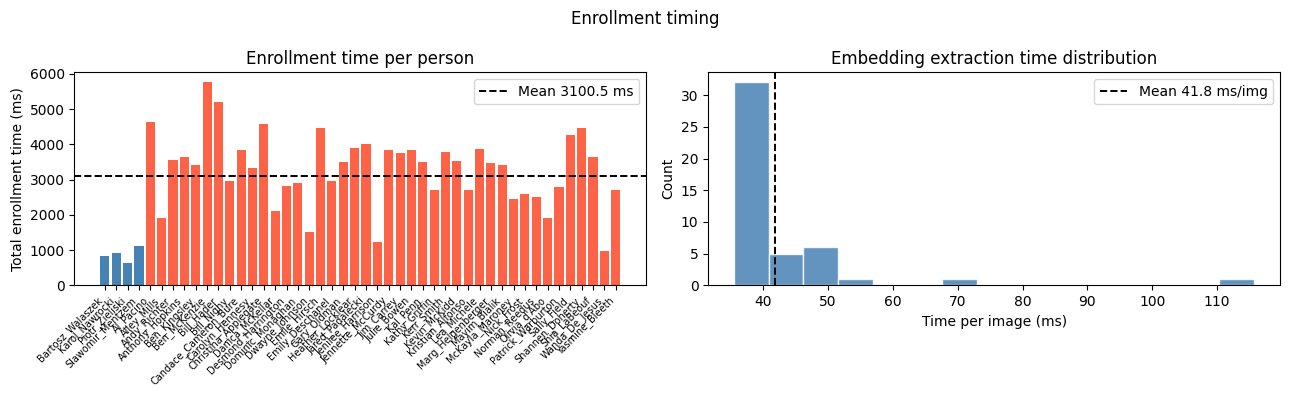

In [5]:
out_dir = Path('../results/task5')
out_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Total enrollment time per person
axes[0].bar(range(len(df_enroll)), df_enroll['t_total_ms'],
            color=['steelblue' if s == 'tttt' else 'tomato'
                   for s in df_enroll['source']])
axes[0].axhline(df_enroll['t_total_ms'].mean(), color='k', ls='--', lw=1.4,
                label=f'Mean {df_enroll["t_total_ms"].mean():.1f} ms')
axes[0].set_xticks(range(len(df_enroll)))
axes[0].set_xticklabels(df_enroll['user_id'], rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Total enrollment time (ms)')
axes[0].set_title('Enrollment time per person')
axes[0].legend()

# Per-image embedding time distribution
axes[1].hist(df_enroll['t_per_image_ms'], bins=15, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[1].axvline(df_enroll['t_per_image_ms'].mean(), color='k', ls='--', lw=1.4,
                label=f'Mean {df_enroll["t_per_image_ms"].mean():.1f} ms/img')
axes[1].set_xlabel('Time per image (ms)')
axes[1].set_ylabel('Count')
axes[1].set_title('Embedding extraction time distribution')
axes[1].legend()

plt.suptitle('Enrollment timing', fontsize=12)
plt.tight_layout()
plt.savefig(out_dir / 'enrollment_timing.png', dpi=150)
plt.show()

## 4b. Enrollment time vs number of images

Does enrollment time scale linearly with the number of images?  
We fit a linear regression and check how well it explains the variance.

Linear regression: t_total = 36.99 * n_images + 205.39 ms
  R²      = 0.8929  (1.0 = perfect linear fit)
  p-value = 0.0000
  Slope   = 36.99 ms/image  ← average time added per extra image
  Intercept = 205.39 ms  ← fixed overhead (DB write, averaging)


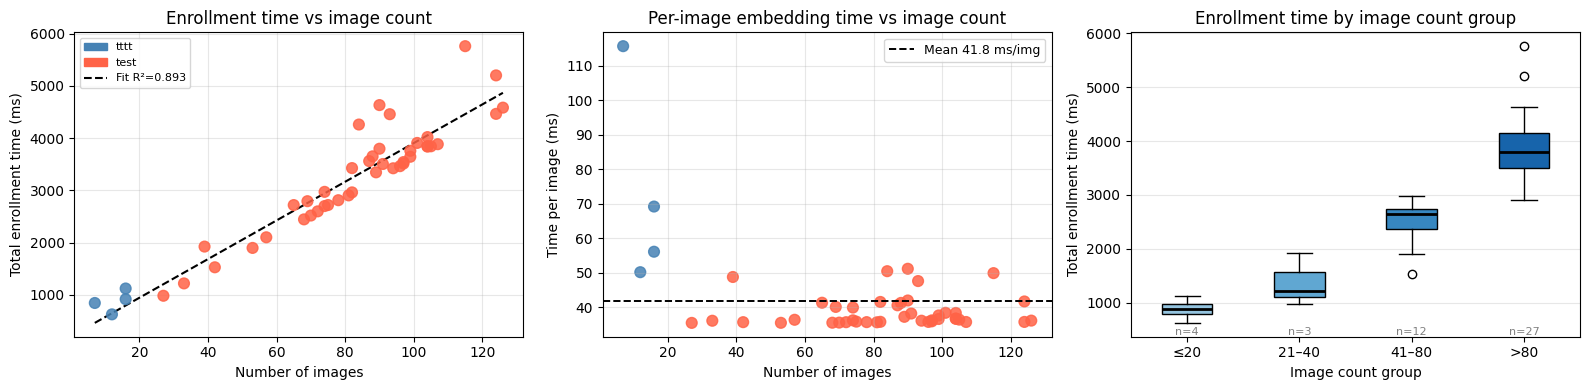

,Group,Persons,Avg images,Mean total (ms),Std total (ms),Mean/img (ms)
0,≤20,4,12.8,878.3,204.2,72.8
1,21–40,3,33.0,1375.7,489.5,40.2
2,41–80,12,66.4,2483.7,428.0,37.0
3,>80,27,98.3,3895.6,634.4,39.5


In [6]:
from scipy import stats as scipy_stats

n_imgs   = df_enroll['n_images'].values.astype(float)
t_total  = df_enroll['t_total_ms'].values
t_per    = df_enroll['t_per_image_ms'].values

# Linear fit: t_total = a * n_imgs + b
slope, intercept, r_value, p_value, stderr = scipy_stats.linregress(n_imgs, t_total)
x_fit = np.linspace(n_imgs.min(), n_imgs.max(), 200)
y_fit = slope * x_fit + intercept

print(f'Linear regression: t_total = {slope:.2f} * n_images + {intercept:.2f} ms')
print(f'  R²      = {r_value**2:.4f}  (1.0 = perfect linear fit)')
print(f'  p-value = {p_value:.4f}')
print(f'  Slope   = {slope:.2f} ms/image  ← average time added per extra image')
print(f'  Intercept = {intercept:.2f} ms  ← fixed overhead (DB write, averaging)')

# Group by image count bins for box comparison
bins   = [0, 20, 40, 80, 200]
labels = ['≤20', '21–40', '41–80', '>80']
df_enroll['n_bin'] = pd.cut(df_enroll['n_images'], bins=bins, labels=labels)
groups = [df_enroll[df_enroll['n_bin'] == lbl]['t_total_ms'].values
          for lbl in labels]
groups = [g for g in groups if len(g) > 0]
group_labels = [lbl for lbl, g in zip(labels,
                [df_enroll[df_enroll['n_bin'] == lbl]['t_total_ms'].values
                 for lbl in labels]) if len(g) > 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Scatter + regression ──────────────────────────────────────────────────────
colors_scatter = ['steelblue' if s == 'tttt' else 'tomato'
                  for s in df_enroll['source']]
axes[0].scatter(n_imgs, t_total, c=colors_scatter, s=60, zorder=3, alpha=0.85)
axes[0].plot(x_fit, y_fit, 'k--', lw=1.5,
             label=f'Fit: {slope:.1f}×n + {intercept:.0f}  R²={r_value**2:.3f}')
axes[0].set_xlabel('Number of images')
axes[0].set_ylabel('Total enrollment time (ms)')
axes[0].set_title('Enrollment time vs image count')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
# Legend for source colours
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='steelblue', label='tttt'),
    Patch(color='tomato',    label='test'),
    plt.Line2D([0],[0], color='k', ls='--', label=f'Fit R²={r_value**2:.3f}'),
], fontsize=8)

# ── Per-image time vs image count (should be ~constant if truly linear) ───────
axes[1].scatter(n_imgs, t_per, c=colors_scatter, s=60, alpha=0.85)
axes[1].axhline(t_per.mean(), color='k', ls='--', lw=1.4,
                label=f'Mean {t_per.mean():.1f} ms/img')
axes[1].set_xlabel('Number of images')
axes[1].set_ylabel('Time per image (ms)')
axes[1].set_title('Per-image embedding time vs image count')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# ── Box plot by bin ───────────────────────────────────────────────────────────
bp = axes[2].boxplot(groups, labels=group_labels, patch_artist=True,
                     medianprops=dict(color='k', lw=2))
cmap = plt.cm.Blues(np.linspace(0.4, 0.8, len(groups)))
for patch, color in zip(bp['boxes'], cmap):
    patch.set_facecolor(color)
axes[2].set_xlabel('Image count group')
axes[2].set_ylabel('Total enrollment time (ms)')
axes[2].set_title('Enrollment time by image count group')
axes[2].grid(axis='y', alpha=0.3)

# Annotate with group sizes
for i, (lbl, grp) in enumerate(zip(group_labels, groups), 1):
    axes[2].text(i, axes[2].get_ylim()[0], f'n={len(grp)}',
                 ha='center', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(out_dir / 'enrollment_vs_n_images.png', dpi=150)
plt.show()

# Per-group summary table
rows_g = []
for lbl in labels:
    grp = df_enroll[df_enroll['n_bin'] == lbl]
    if grp.empty:
        continue
    rows_g.append({
        'Group':            lbl,
        'Persons':          len(grp),
        'Avg images':       round(grp['n_images'].mean(), 1),
        'Mean total (ms)':  round(grp['t_total_ms'].mean(), 1),
        'Std total (ms)':   round(grp['t_total_ms'].std(), 1),
        'Mean/img (ms)':    round(grp['t_per_image_ms'].mean(), 1),
    })
display(pd.DataFrame(rows_g))

## 5. Verification (1:1) and Identification (1:N) timing

Use images from `data/tttt/` as probes against the **existing enrolled DB** (not the temporarily enrolled persons).

In [7]:
# Pick probe images — one per tttt person
probe_imgs  = []
for _, person_dir in [c for c in candidate_dirs if c[0] == 'tttt']:
    imgs = load_person_dir(person_dir)
    if imgs:
        probe_imgs.append(imgs[0])

# Fallback: use first test person if tttt is empty
if not probe_imgs:
    _, person_dir = candidate_dirs[0]
    probe_imgs = load_person_dir(person_dir)[:1]

# Use one enrolled user for 1:1 verification
verify_user = list(enrolled_users)[0]

print(f'Probe images       : {len(probe_imgs)}')
print(f'Verification user  : {verify_user}')
print(f'DB size            : {len(enrolled_users)} users')
print(f'Repetitions        : {N_RUNS}')

Probe images       : 4
Verification user  : Andrea_Bowen
DB size            : 105 users
Repetitions        : 30


In [8]:
verify_times   = []
identify_times = []
embed_times    = []

for probe_img in probe_imgs:
    for _ in range(N_RUNS):
        # Embedding only
        t0 = time.perf_counter()
        emb = get_embedding(app, probe_img, fallback=True)
        embed_times.append((time.perf_counter() - t0) * 1000)

        if emb is None:
            continue

        # 1:1 verification
        t0 = time.perf_counter()
        _  = get_embedding(app, probe_img, fallback=True)
        _  = db.query_user(verify_user, emb)
        verify_times.append((time.perf_counter() - t0) * 1000)

        # 1:N identification
        t0 = time.perf_counter()
        _  = get_embedding(app, probe_img, fallback=True)
        _  = db.query_top1(emb)
        identify_times.append((time.perf_counter() - t0) * 1000)

embed_times    = np.array(embed_times)
verify_times   = np.array(verify_times)
identify_times = np.array(identify_times)

t_embed_mean = embed_times.mean()

for label, arr in [
    ('Embedding only',      embed_times),
    ('Verification (1:1)',  verify_times),
    ('Identification (1:N)', identify_times),
]:
    print(f'{label:<25s}  mean={arr.mean():6.2f} ms  '
          f'std={arr.std():5.2f} ms  '
          f'min={arr.min():6.2f} ms  '
          f'max={arr.max():6.2f} ms  '
          f'(n={len(arr)})')

Embedding only             mean= 41.14 ms  std=10.30 ms  min= 35.18 ms  max=122.28 ms  (n=120)
Verification (1:1)         mean= 42.23 ms  std= 7.58 ms  min= 35.76 ms  max= 89.69 ms  (n=120)
Identification (1:N)       mean= 43.20 ms  std= 7.38 ms  min= 36.90 ms  max= 84.53 ms  (n=120)


## 6. Timing distributions

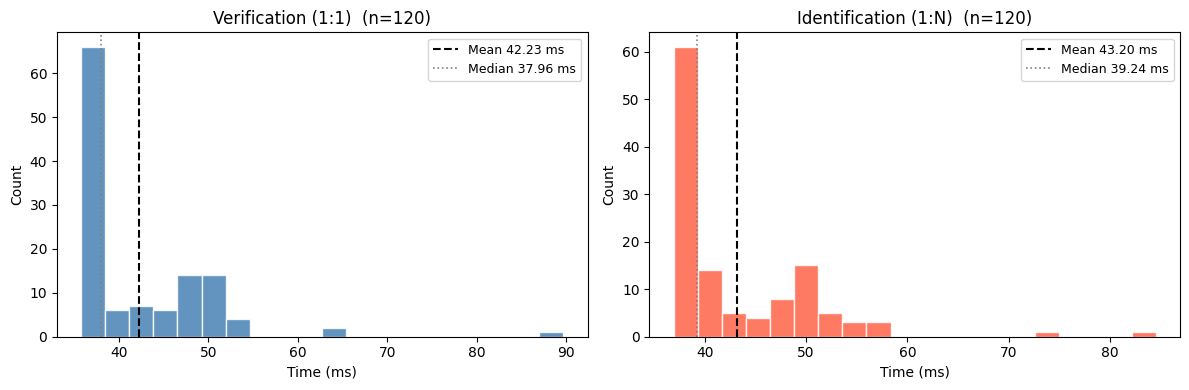

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, times, label, color in [
    (axes[0], verify_times,   'Verification (1:1)', 'steelblue'),
    (axes[1], identify_times, 'Identification (1:N)', 'tomato'),
]:
    ax.hist(times, bins=20, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(times.mean(),   color='k',    ls='--', lw=1.5,
               label=f'Mean {times.mean():.2f} ms')
    ax.axvline(np.median(times), color='gray', ls=':',  lw=1.2,
               label=f'Median {np.median(times):.2f} ms')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label}  (n={len(times)})')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(out_dir / 'timing_distributions.png', dpi=150)
plt.show()

## 7. 1:N identification scaling estimate (HNSW O(log N))

Embedding (constant)    : 41.14 ms
HNSW search @ 105 users : 2.06 ms


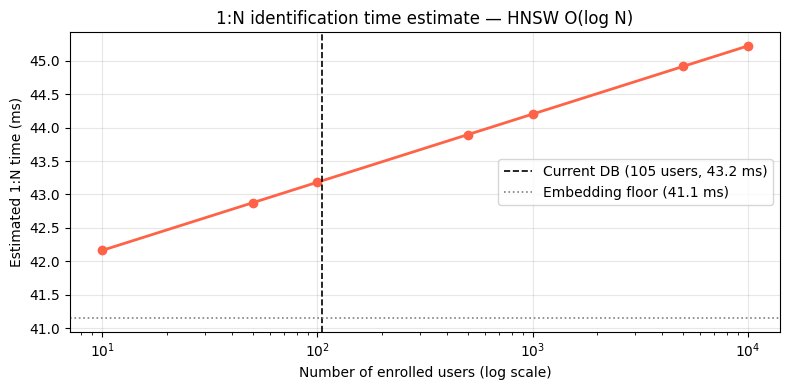

,DB size,Estimated 1:N time (ms)
0,10,42.16
1,50,42.88
2,100,43.18
3,500,43.90
4,1000,44.20
5,5000,44.92
6,10000,45.22


In [10]:
t_id_mean    = identify_times.mean()
t_db_search  = t_id_mean - t_embed_mean   # time spent in HNSW query
current_size = len(enrolled_users)

print(f'Embedding (constant)    : {t_embed_mean:.2f} ms')
print(f'HNSW search @ {current_size} users : {t_db_search:.2f} ms')

db_sizes  = [10, 50, 100, 500, 1000, 5000, 10000]
estimated = [
    t_embed_mean + t_db_search * np.log(max(n, 2)) / max(np.log(current_size), 1e-9)
    for n in db_sizes
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(db_sizes, estimated, 'o-', color='tomato', lw=2)
ax.axvline(current_size, color='k', ls='--', lw=1.2,
           label=f'Current DB ({current_size} users, {t_id_mean:.1f} ms)')
ax.axhline(t_embed_mean, color='gray', ls=':', lw=1.2,
           label=f'Embedding floor ({t_embed_mean:.1f} ms)')
ax.set_xscale('log')
ax.set_xlabel('Number of enrolled users (log scale)')
ax.set_ylabel('Estimated 1:N time (ms)')
ax.set_title('1:N identification time estimate — HNSW O(log N)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir / 'identification_scaling.png', dpi=150)
plt.show()

df_est = pd.DataFrame({'DB size': db_sizes,
                       'Estimated 1:N time (ms)': [round(t, 2) for t in estimated]})
display(df_est)

## 8. Summary

In [11]:
print('=' * 62)
print('TASK 5 — TIMING RESULTS')
print('=' * 62)
print(f'  Persons used for enrollment timing : {len(df_enroll)}')
print(f'    from data/tttt/                  : '
      f'{(df_enroll["source"]=="tttt").sum()}')
print(f'    from data/test/                  : '
      f'{(df_enroll["source"]=="test").sum()}')
print(f'  DB size during verify/identify     : {current_size} users')
print(f'  Repetitions per probe              : {N_RUNS}')
print()
print('  --- Enrollment ---')
print(f'  Embedding / image   mean : {df_enroll["t_per_image_ms"].mean():6.1f} ms  '
      f'std : {df_enroll["t_per_image_ms"].std():.1f} ms')
print(f'  DB write            mean : {df_enroll["t_db_write_ms"].mean():6.1f} ms  '
      f'std : {df_enroll["t_db_write_ms"].std():.1f} ms')
print(f'  Total enrollment    mean : {df_enroll["t_total_ms"].mean():6.1f} ms  '
      f'std : {df_enroll["t_total_ms"].std():.1f} ms')
print()
print('  --- Single query ---')
print(f'  Embedding only      mean : {embed_times.mean():6.2f} ms  '
      f'std : {embed_times.std():.2f} ms')
print(f'  Verification (1:1)  mean : {verify_times.mean():6.2f} ms  '
      f'std : {verify_times.std():.2f} ms')
print(f'  Identification (1:N)mean : {identify_times.mean():6.2f} ms  '
      f'std : {identify_times.std():.2f} ms')
print(f'    of which HNSW search   : {t_db_search:6.2f} ms  (O(log N))')
print('=' * 62)

TASK 5 — TIMING RESULTS
  Persons used for enrollment timing : 46
    from data/tttt/                  : 4
    from data/test/                  : 42
  DB size during verify/identify     : 105 users
  Repetitions per probe              : 30

  --- Enrollment ---
  Embedding / image   mean :   41.8 ms  std : 13.1 ms
  DB write            mean :   23.4 ms  std : 7.2 ms
  Total enrollment    mean : 3100.5 ms  std : 1186.9 ms

  --- Single query ---
  Embedding only      mean :  41.14 ms  std : 10.30 ms
  Verification (1:1)  mean :  42.23 ms  std : 7.58 ms
  Identification (1:N)mean :  43.20 ms  std : 7.38 ms
    of which HNSW search   :   2.06 ms  (O(log N))
